In [1]:
import math 
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# --- physical properties ---
rho = 1000       # kg/m3
g = 9.81         # m/s2
mu = 1e-3        # Pa·s

# --- permeability ---
k_intrinsic = 1e-12   # m2 (FIXED: realistic!)
K = k_intrinsic * rho * g / mu   # hydraulic conductivity

# --- geometry ---
r_sample = 0.01   # m
r_pipe   = 0.005  # m
L        = 0.1    # m

# --- experiment input ---
V_added = 1e-4   # m3 (100 mL)

# --- time ---
t_end = 60000
dt = 0.1   # FIXED: smaller timestep

In [3]:
def falling_head(
    t_end,
    dt,
    K,
    r_sample,
    r_pipe,
    L,
    V_added
):

    t = np.arange(0, t_end + dt, dt)

    h = np.zeros_like(t)
    Q = np.zeros_like(t)
    v = np.zeros_like(t)

    # areas
    A_sample = math.pi * r_sample**2
    A_pipe   = math.pi * r_pipe**2

    # initial head from volume
    h[0] = V_added / A_pipe

    for i in range(1, len(t)):

        # Darcy flow
        Q[i-1] = K * A_sample * h[i-1] / L

        # velocity
        v[i-1] = Q[i-1] / A_sample

        # head decay
        dhdt = -Q[i-1] / A_pipe

        # update (stable)
        h[i] = max(h[i-1] + dhdt * dt, 0)

    return t, h, Q, v

In [4]:
t, h, Q, v = falling_head(
    t_end,
    dt,
    K,
    r_sample,
    r_pipe,
    L,
    V_added
)

In [5]:
Q

array([3.92400000e-08, 3.92384602e-08, 3.92369205e-08, ...,
       2.33632459e-18, 2.33623292e-18, 0.00000000e+00], shape=(600001,))

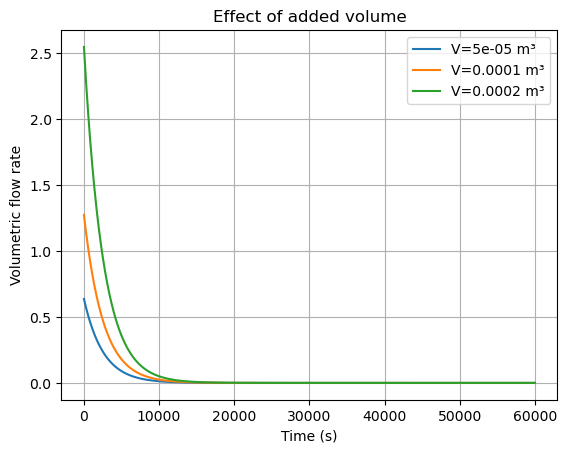

In [6]:
volumes = [5e-5, 1e-4, 2e-4]

plt.figure()

for V in volumes:
    t, Q, _, _ = falling_head(t_end, dt, K, r_sample, r_pipe, L, V)
    plt.plot(t, Q, label=f"V={V} m³")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Volumetric flow rate")
plt.title("Effect of added volume")
plt.grid()
plt.savefig("added_water_volume_Q_time_effect.png", dpi=300)
plt.show()

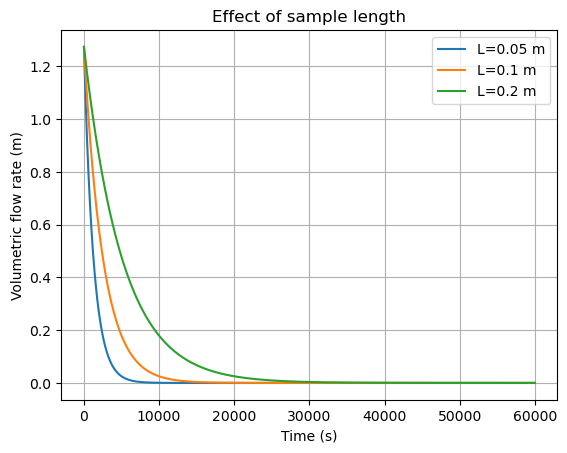

In [7]:
lengths = [0.05, 0.1, 0.2]

plt.figure()

for L_val in lengths:
    t, Q, _, _ = falling_head(t_end, dt, K, r_sample, r_pipe, L_val, V_added)
    plt.plot(t, Q, label=f"L={L_val} m")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Volumetric flow rate (m)")
plt.title("Effect of sample length")
plt.grid()
plt.savefig("sample_length_Q_time_effect.png",dpi=300)
plt.show()

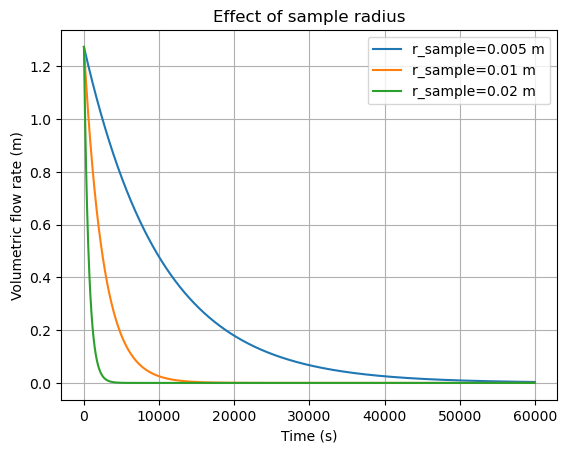

In [8]:
radii = [0.005, 0.01, 0.02]

plt.figure()

for r in radii:
    t, Q, _, _ = falling_head(t_end, dt, K, r, r_pipe, L, V_added)
    plt.plot(t, Q, label=f"r_sample={r} m")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Volumetric flow rate (m)")
plt.title("Effect of sample radius")
plt.grid()
plt.savefig("sample_radius_Q_time_effect",dpi=300)
plt.show()

# concentration vs volume estimate


Assume Oyster shells used; have a dry weight that we estimate to consist for 95\% of CaCO3. 

We assume dissolution first; use dissolution rate laws; so related to the grain geometry

We use small grains (less than 63 micro meter), medium grainsize (63-250) or large (above 1mm, 1000 micrometer)



In [9]:
pH_values=np.linspace(1, 8.1, 8)

grain_sizes=np.array([63,250,1000])*10**(-6) #based on preliminary estimates 

# Volume of acidic water [L]
V_water = 1.0

# Calcium carbonate purity
purity = 0.95

# Molecular weight of CaCO3 [g/mol]
MW_CaCO3 = 100.09

# Initial material mass [g]
initial_mass = 5.0

# Dissolution kinetics constant
# empirical tuning parameter
k = 1e-5

# Reaction order
n = 1.0

# Density CaCO3 [g/cm3]
rho = 2.71



In [10]:
time = np.linspace(0, t_end, 20)


In [11]:
results = []

for pH in pH_values:

    # H+ concentration [mol/L]
    H_conc = 10**(-pH)

    # Total moles H+
    mol_H = H_conc * V_water

    # Moles CaCO3 needed
    # 1 mol CaCO3 neutralizes 2 mol H+
    mol_CaCO3 = mol_H / 2

    # Pure CaCO3 mass [g]
    mass_CaCO3 = mol_CaCO3 * MW_CaCO3

    # Correct for 95% purity
    mass_material = mass_CaCO3 / purity

    for gs in grain_sizes:

        results.append({
            "pH": pH,
            "grain_size_um": gs,
            "mass_material_g": mass_material,
            "active_CaCO3_g": mass_CaCO3
        })


df = pd.DataFrame(results)

print(df)




          pH  grain_size_um  mass_material_g  active_CaCO3_g
0   1.000000       0.000063     5.267895e+00    5.004500e+00
1   1.000000       0.000250     5.267895e+00    5.004500e+00
2   1.000000       0.001000     5.267895e+00    5.004500e+00
3   2.014286       0.000063     5.097431e-01    4.842560e-01
4   2.014286       0.000250     5.097431e-01    4.842560e-01
5   2.014286       0.001000     5.097431e-01    4.842560e-01
6   3.028571       0.000063     4.932484e-02    4.685860e-02
7   3.028571       0.000250     4.932484e-02    4.685860e-02
8   3.028571       0.001000     4.932484e-02    4.685860e-02
9   4.042857       0.000063     4.772874e-03    4.534230e-03
10  4.042857       0.000250     4.772874e-03    4.534230e-03
11  4.042857       0.001000     4.772874e-03    4.534230e-03
12  5.057143       0.000063     4.618429e-04    4.387507e-04
13  5.057143       0.000250     4.618429e-04    4.387507e-04
14  5.057143       0.001000     4.618429e-04    4.387507e-04
15  6.071429       0.000

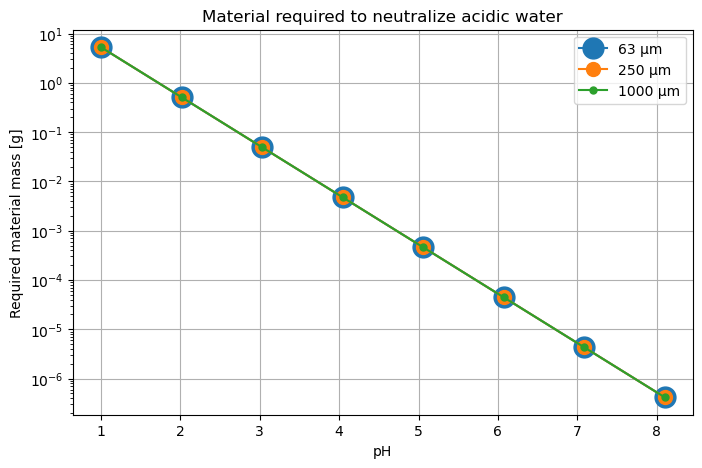

In [12]:
plt.figure(figsize=(8,5))

sizes = [15,10,5 ]
for i, gs in enumerate(grain_sizes):
    subset = df[df["grain_size_um"] == gs]

    plt.plot(
        subset["pH"],
        subset["mass_material_g"],
        marker='o',
        markersize=sizes[i],
        label=f"{gs*1e6:.0f} µm"
    )

plt.yscale("log")
plt.xlabel("pH")
plt.ylabel("Required material mass [g]")
plt.title("Material required to neutralize acidic water")
plt.grid(True)
plt.legend()

plt.show()

In [25]:
def specific_surface_area(d_um):
    """
    Approximate surface area scaling.
    Spheres assumed.

    Returns relative area [m2/g]
    """

    d_m = d_um * 1e-6

    # sphere geometry
    SSA = 6 / (rho * 1000 * d_m)

    return SSA

# ============================================================
# MAIN SIMULATION
# ============================================================

results = []

for pH0 in pH_values:

    for d in df['grain_size_um']:

        # Initial H+
        H = 10**(-pH0)

        # Initial moles H+
        mol_H = H * V_water

        # Initial CaCO3 mass
        mass = initial_mass

        # Reactive surface area factor
        SSA = specific_surface_area(d)

        pH_history = []
        mass_history = []
        dissolved_history = []

        dissolved_total = 0

        for t in time:

            if mass <= 0:
                break

            if mol_H <= 0:
                break

            # Current H+
            H_conc = mol_H / V_water

            # Surface area decreases with remaining mass
            area = SSA * mass

            # Dissolution rate [mol/s]
            rate = k * area * (H_conc**n)

            # Dissolved during timestep
            dmol = rate * dt

            # Convert to grams
            dmass_CaCO3 = dmol * MW_CaCO3

            # Correct for purity
            dmass_material = dmass_CaCO3 / purity

            # Prevent over-dissolution
            dmass_material = min(dmass_material, mass)

            # Recompute actual dissolved moles
            dmol_actual = dmass_material * purity / MW_CaCO3

            # Neutralization:
            # 1 mol CaCO3 consumes 2 mol H+
            dH = 2 * dmol_actual

            dH = min(dH, mol_H)

            # Update system
            mol_H -= dH
            mass -= dmass_material

            dissolved_total += dmass_material

            # Current pH
            H_conc = max(mol_H / V_water, 1e-14)
            pH_current = -np.log10(H_conc)

            # Save history
            pH_history.append(pH_current)
            mass_history.append(mass)
            dissolved_history.append(dissolved_total)

        # Save results
        results.append({
            "pH0": pH0,
            "grain_size": d,
            "time": time[:len(pH_history)],
            "pH_history": pH_history,
            "mass_history": mass_history,
            "dissolved_history": dissolved_history
        })

results=pd.DataFrame(results)

In [27]:
print(results['pH_history'])

0      [2.293672906913151]
1      [2.293672906913151]
2      [2.293672906913151]
3      [2.293672906913151]
4      [2.293672906913151]
              ...         
187                 [14.0]
188                 [14.0]
189                 [14.0]
190                 [14.0]
191                 [14.0]
Name: pH_history, Length: 192, dtype: object


C:\Users\fionn\AppData\Local\Temp\ipykernel_3948\630896655.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


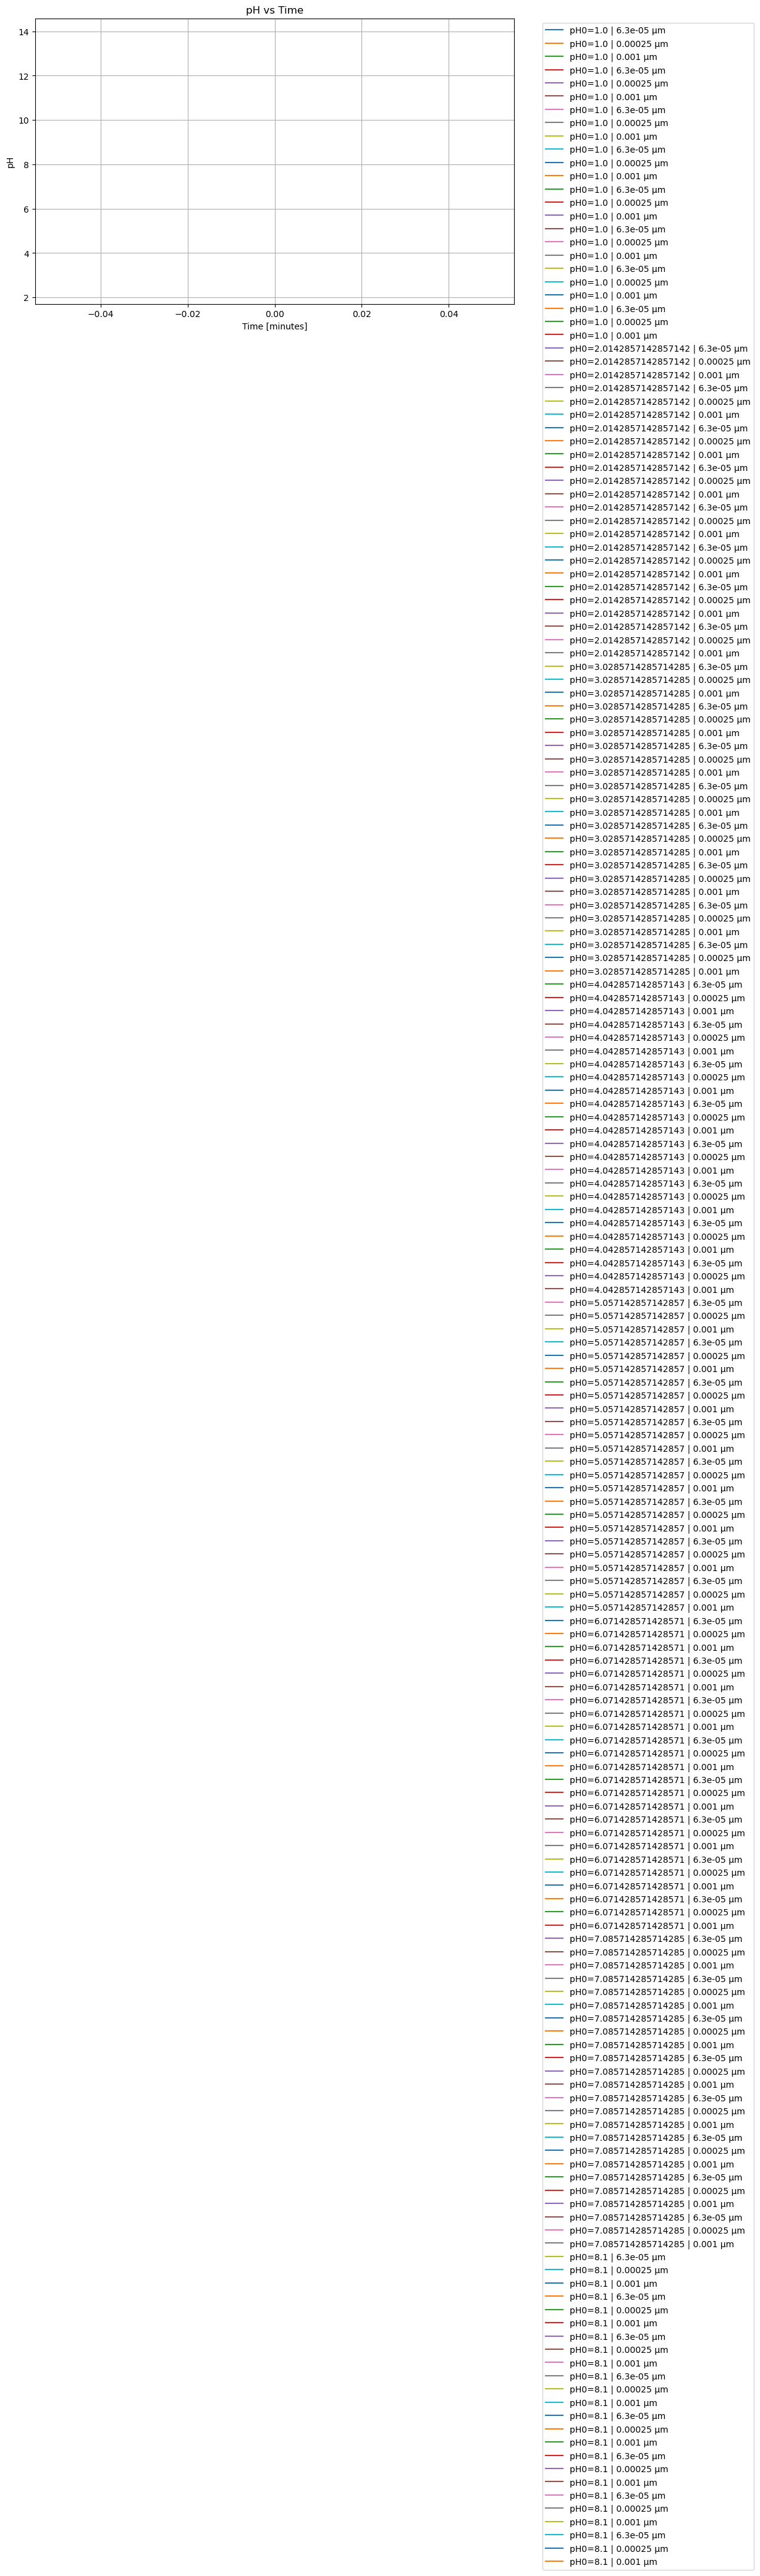

In [33]:
plt.figure(figsize=(10,6))

colors = {
    6.3e-05: "C0",
    0.00025: "C1",
    0.001: "C2"
}
seen = set()

for _, r in results.iterrows():
    gs = float(r['grain_size'])
    label = f"{int(gs * 1e6)} µm" if gs not in seen else "_nolegend_"
    seen.add(gs)

    plt.plot(
        np.array(r["time"]) / 60,
        np.array(r["pH_history"]),
        color=colors.get(gs, None),
        label=label,
        alpha=0.8
    )

plt.xlabel("Time [minutes]")
plt.ylabel("pH")
plt.title("pH vs Time")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

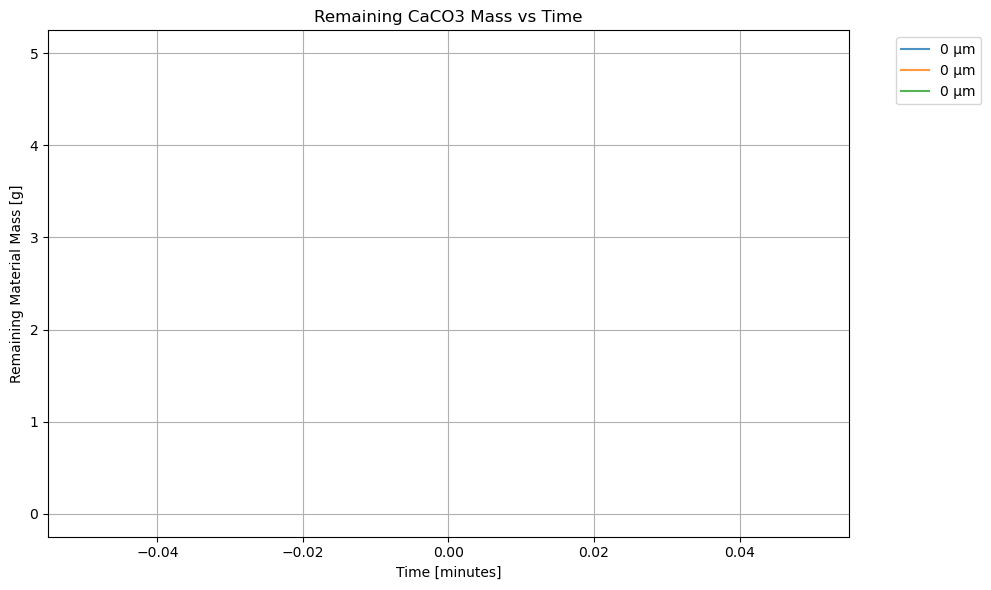

In [34]:
plt.figure(figsize=(10,6))

colors = {
    63.0: "C0",
    250.0: "C1",
    1000.0: "C2"
}
seen = set()

for _, r in results.iterrows():
    gs = float(r['grain_size'])
    label = f"{int(gs)} µm" if gs not in seen else None
    seen.add(gs)

    plt.plot(
        np.array(r["time"]) / 60,
        r["mass_history"],
        color=colors.get(gs, None),
        label=label,
        alpha=0.8
    )

plt.xlabel("Time [minutes]")
plt.ylabel("Remaining Material Mass [g]")
plt.title("Remaining CaCO3 Mass vs Time")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

In [31]:
plt.figure(figsize=(10,6))

colors = {
    63.0: "C0",
    250.0: "C1",
    1000.0: "C2"
}
seen = set()

for _, r in results.iterrows():
    gs = float(r['grain_size'])
    label = f"{int(gs)} µm" if gs not in seen else None
    seen.add(gs)

    plt.plot(
        np.array(r["time"]) / 60,
        r["dissolved_history"],
        color=colors.get(gs, None),
        label=label,
        alpha=0.8
    )

plt.xlabel("Time [minutes]")
plt.ylabel("Dissolved Material [g]")
plt.title("Dissolved CaCO3 vs Time")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

TypeError: string indices must be integers, not 'str'

<Figure size 1000x600 with 0 Axes>